In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"E:\INTERNSHIP PROJECT\Orbital Decay Analytics\data\space_decay.csv")

df.head()

,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,ORIGINATOR,OBJECT_NAME,OBJECT_ID,CENTER_NAME,REF_FRAME,TIME_SYSTEM,MEAN_ELEMENT_THEORY,...,RCS_SIZE,COUNTRY_CODE,LAUNCH_DATE,SITE,DECAY_DATE,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2
0,2,GENERATED VIA SPACE-TRACK.ORG API,2021-11-01T06:46:11,18 SPCS,ARIANE 42P+ DEB,1992-072J,EARTH,TEME,UTC,SGP4,...,MEDIUM,FR,1992.0,FRGUI,NaN,3195178,188614016,0 ARIANE 42P+ DEB,1 26741U 92072J 21304.94919376 .00000883 0...,2 26741 7.7156 90.2410 6528926 243.1216 38...
1,2,GENERATED VIA SPACE-TRACK.ORG API,2021-11-01T04:58:37,18 SPCS,SL-8 DEB,1979-028C,EARTH,TEME,UTC,SGP4,...,SMALL,CIS,1979.0,PKMTR,NaN,3194950,188593285,0 SL-8 DEB,1 26743U 79028C 21304.68908982 .00000079 0...,2 26743 82.9193 299.1120 0030720 158.9093 201...
2,2,GENERATED VIA SPACE-TRACK.ORG API,2021-11-01T06:26:11,18 SPCS,GSAT 1,2001-015A,EARTH,TEME,UTC,SGP4,...,LARGE,IND,2001.0,SRI,NaN,3195026,188609573,0 GSAT 1,1 26745U 01015A 21305.22411368 -.00000165 0...,2 26745 12.1717 16.5368 0237386 250.1248 146...
3,2,GENERATED VIA SPACE-TRACK.ORG API,2021-10-31T18:07:15,18 SPCS,CZ-4 DEB,1999-057MB,EARTH,TEME,UTC,SGP4,...,SMALL,PRC,1999.0,TSC,NaN,3194431,188556894,0 CZ-4 DEB,1 26754U 99057MB 21304.46625230 .00002265 0...,2 26754 98.4781 8.7205 0060618 37.3771 323...
4,2,GENERATED VIA SPACE-TRACK.ORG API,2021-11-01T04:58:37,18 SPCS,CZ-4 DEB,1999-057MC,EARTH,TEME,UTC,SGP4,...,SMALL,PRC,1999.0,TSC,NaN,3194950,188592541,0 CZ-4 DEB,1 26755U 99057MC 21304.74081807 .00002610 0...,2 26755 98.4232 122.0724 0062255 345.1605 27...


In [4]:
df.shape

(14372, 40)

In [5]:
df.columns

Index(['CCSDS_OMM_VERS', 'COMMENT', 'CREATION_DATE', 'ORIGINATOR',
       'OBJECT_NAME', 'OBJECT_ID', 'CENTER_NAME', 'REF_FRAME', 'TIME_SYSTEM',
       'MEAN_ELEMENT_THEORY', 'EPOCH', 'MEAN_MOTION', 'ECCENTRICITY',
       'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY',
       'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE', 'NORAD_CAT_ID',
       'ELEMENT_SET_NO', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT',
       'MEAN_MOTION_DDOT', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOAPSIS', 'PERIAPSIS',
       'OBJECT_TYPE', 'RCS_SIZE', 'COUNTRY_CODE', 'LAUNCH_DATE', 'SITE',
       'DECAY_DATE', 'FILE', 'GP_ID', 'TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14372 entries, 0 to 14371
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CCSDS_OMM_VERS       14372 non-null  int64  
 1   COMMENT              14372 non-null  str    
 2   CREATION_DATE        14372 non-null  str    
 3   ORIGINATOR           14372 non-null  str    
 4   OBJECT_NAME          14372 non-null  str    
 5   OBJECT_ID            14333 non-null  str    
 6   CENTER_NAME          14372 non-null  str    
 7   REF_FRAME            14372 non-null  str    
 8   TIME_SYSTEM          14372 non-null  str    
 9   MEAN_ELEMENT_THEORY  14372 non-null  str    
 10  EPOCH                14372 non-null  str    
 11  MEAN_MOTION          14372 non-null  float64
 12  ECCENTRICITY         14372 non-null  float64
 13  INCLINATION          14372 non-null  float64
 14  RA_OF_ASC_NODE       14372 non-null  float64
 15  ARG_OF_PERICENTER    14372 non-null  float64
 1

In [7]:
df.describe()

,CCSDS_OMM_VERS,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,LAUNCH_DATE,DECAY_DATE,FILE,GP_ID
count,14372.0,14372.000000,14372.000000,14372.000000,14372.000000,14372.000000,14372.000000,14372.0,14372.000000,14372.0,...,14372.000000,1.437200e+04,14372.000000,14372.000000,14372.000000,14372.000000,14333.000000,0.0,1.437200e+04,1.437200e+04
mean,2.0,12.463847,0.067168,74.354208,182.353111,165.977199,191.015595,0.0,39558.160381,999.0,...,0.000049,2.307751e-07,10636.185210,223.521557,5721.060178,2795.040245,2004.507570,NaN,3.194186e+06,1.885638e+08
std,0.0,4.509305,0.181547,29.626780,116.717713,104.461866,109.873807,0.0,7619.846133,0.0,...,0.002391,1.485939e-05,9580.627227,446.517041,13016.299008,7943.045264,13.565227,NaN,3.119117e+03,1.393616e+05
min,2.0,0.051783,0.000005,0.001400,0.020000,0.008200,0.004800,0.0,26741.000000,999.0,...,-0.014873,-4.210300e-05,6542.850000,87.783000,183.393000,73.279000,1961.000000,NaN,3.142499e+06,1.860926e+08
25%,2.0,13.452144,0.000725,53.055300,71.987350,77.363475,90.001600,0.0,33965.750000,999.0,...,0.000001,0.000000e+00,6956.246750,96.232750,599.876000,546.115000,1997.000000,NaN,3.194431e+06,1.885665e+08
50%,2.0,14.277052,0.003416,86.369200,189.460250,150.483900,206.957400,0.0,40165.500000,999.0,...,0.000010,0.000000e+00,7177.549000,100.861000,843.686000,702.433500,2002.000000,NaN,3.194950e+06,1.885986e+08
75%,2.0,14.963745,0.013505,98.565125,292.484750,258.328550,284.163200,0.0,45173.500000,999.0,...,0.000032,0.000000e+00,7468.055000,107.046000,1207.919500,831.959750,2018.000000,NaN,3.195064e+06,1.886107e+08
max,2.0,16.404097,0.897218,144.586200,359.967900,359.989900,359.981900,0.0,270288.000000,999.0,...,0.225321,1.654800e-03,304049.635000,27808.429000,372136.402000,224547.015000,2021.000000,NaN,3.195727e+06,1.886250e+08


In [8]:
df.isnull().sum()

CCSDS_OMM_VERS             0
COMMENT                    0
CREATION_DATE              0
ORIGINATOR                 0
OBJECT_NAME                0
OBJECT_ID                 39
CENTER_NAME                0
REF_FRAME                  0
TIME_SYSTEM                0
MEAN_ELEMENT_THEORY        0
EPOCH                      0
MEAN_MOTION                0
ECCENTRICITY               0
INCLINATION                0
RA_OF_ASC_NODE             0
ARG_OF_PERICENTER          0
MEAN_ANOMALY               0
EPHEMERIS_TYPE             0
CLASSIFICATION_TYPE        0
NORAD_CAT_ID               0
ELEMENT_SET_NO             0
REV_AT_EPOCH               0
BSTAR                      0
MEAN_MOTION_DOT            0
MEAN_MOTION_DDOT           0
SEMIMAJOR_AXIS             0
PERIOD                     0
APOAPSIS                   0
PERIAPSIS                  0
OBJECT_TYPE                0
RCS_SIZE                 198
COUNTRY_CODE              39
LAUNCH_DATE               39
SITE                      39
DECAY_DATE    

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['COUNTRY_CODE'] = df['COUNTRY_CODE'].fillna('Unknown')

In [12]:
df['SITE'] = df['SITE'].fillna('Unknown')

df['RCS_SIZE'] = df['RCS_SIZE'].fillna(
    df['RCS_SIZE'].mode()[0]
)

In [16]:
df.isnull().sum()

CCSDS_OMM_VERS             0
COMMENT                    0
CREATION_DATE              0
ORIGINATOR                 0
OBJECT_NAME                0
OBJECT_ID                  0
CENTER_NAME                0
REF_FRAME                  0
TIME_SYSTEM                0
MEAN_ELEMENT_THEORY        0
EPOCH                      0
MEAN_MOTION                0
ECCENTRICITY               0
INCLINATION                0
RA_OF_ASC_NODE             0
ARG_OF_PERICENTER          0
MEAN_ANOMALY               0
EPHEMERIS_TYPE             0
CLASSIFICATION_TYPE        0
NORAD_CAT_ID               0
ELEMENT_SET_NO             0
REV_AT_EPOCH               0
BSTAR                      0
MEAN_MOTION_DOT            0
MEAN_MOTION_DDOT           0
SEMIMAJOR_AXIS             0
PERIOD                     0
APOAPSIS                   0
PERIAPSIS                  0
OBJECT_TYPE                0
RCS_SIZE                   0
COUNTRY_CODE               0
LAUNCH_DATE                0
SITE                       0
DECAY_DATE    

In [14]:
df = df.dropna(subset=['LAUNCH_DATE'])

In [15]:
df['OBJECT_ID'] = df['OBJECT_ID'].fillna('Unknown')

In [17]:
df['LAUNCH_DATE'] = pd.to_datetime(df['LAUNCH_DATE'])
df['Launch_Year'] = df['LAUNCH_DATE'].dt.year

In [19]:
country_objects = df.groupby('COUNTRY_CODE')['OBJECT_NAME'].count()

print(country_objects.sort_values(ascending=False).head(10))

COUNTRY_CODE
US     5045
PRC    3924
CIS    3210
UK      391
FR      343
IND     182
JPN     181
TBD     119
ESA      84
GER      58
Name: OBJECT_NAME, dtype: int64


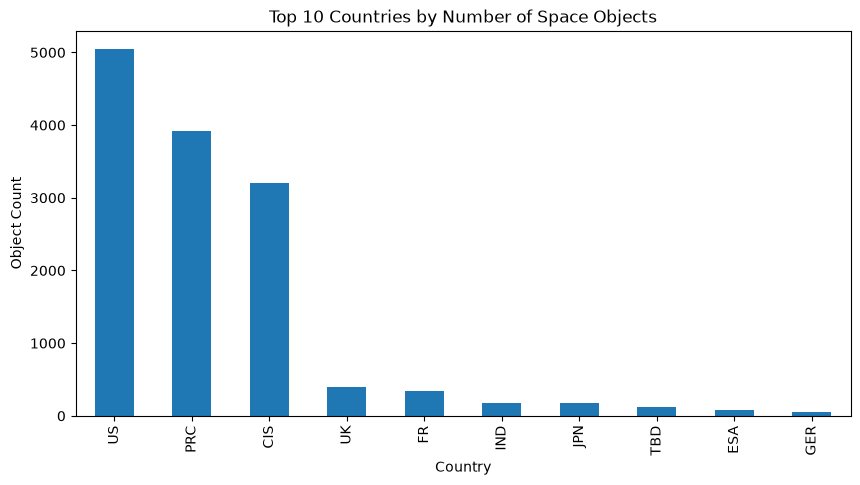

In [20]:
country_objects.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Countries by Number of Space Objects')
plt.xlabel('Country')
plt.ylabel('Object Count')
plt.show()

In [21]:
object_count = df.groupby('OBJECT_TYPE')['OBJECT_NAME'].count()

print(object_count)

OBJECT_TYPE
DEBRIS         8431
PAYLOAD        4950
ROCKET BODY     744
TBA             208
Name: OBJECT_NAME, dtype: int64


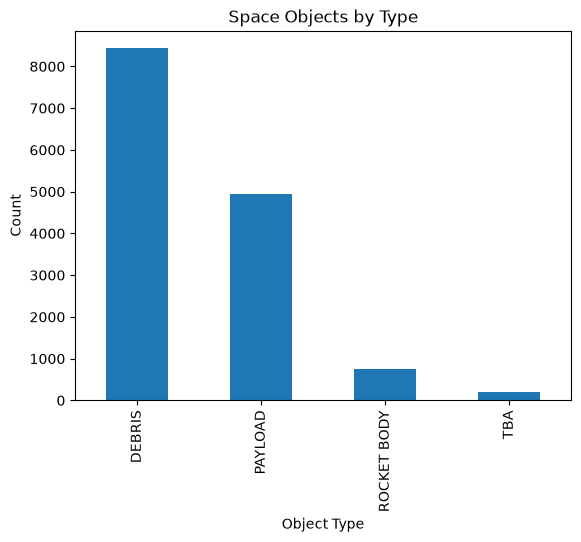

In [22]:
object_count.plot(kind='bar')

plt.title('Space Objects by Type')
plt.xlabel('Object Type')
plt.ylabel('Count')
plt.show()

In [23]:
country_period = df.groupby('COUNTRY_CODE')['PERIOD'].mean()

print(country_period.sort_values(ascending=False).head(10))

COUNTRY_CODE
USBZ    1457.033000
AGO     1449.015000
RASC    1444.866000
SES     1437.498649
ITSO    1436.935400
STCT    1436.140000
BERM    1436.135000
QAT     1436.121000
LAOS    1436.119000
FRIT    1436.115000
Name: PERIOD, dtype: float64


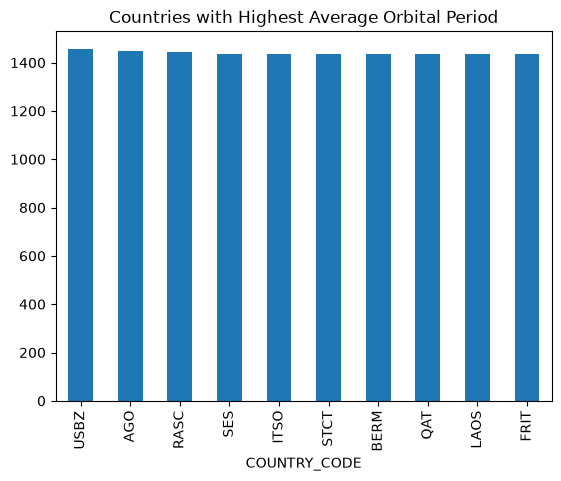

In [24]:
country_period.sort_values(
    ascending=False
).head(10).plot(
    kind='bar'
)

plt.title('Countries with Highest Average Orbital Period')
plt.show()

In [25]:
object_apo = df.groupby(
    'OBJECT_TYPE'
)['APOAPSIS'].mean()

print(object_apo)

OBJECT_TYPE
DEBRIS          4404.626681
PAYLOAD         5864.595972
ROCKET BODY    21281.639313
TBA              560.037562
Name: APOAPSIS, dtype: float64


In [26]:
launch_site = df.groupby(
    'SITE'
)['OBJECT_NAME'].count()

print(
    launch_site.sort_values(
        ascending=False
    ).head(10)
)

SITE
TSC      3150
AFETR    2496
PKMTR    2039
TTMTR    1984
AFWTR    1738
FRGUI     708
SRI       511
JSC       442
XSC       405
VOSTO     290
Name: OBJECT_NAME, dtype: int64


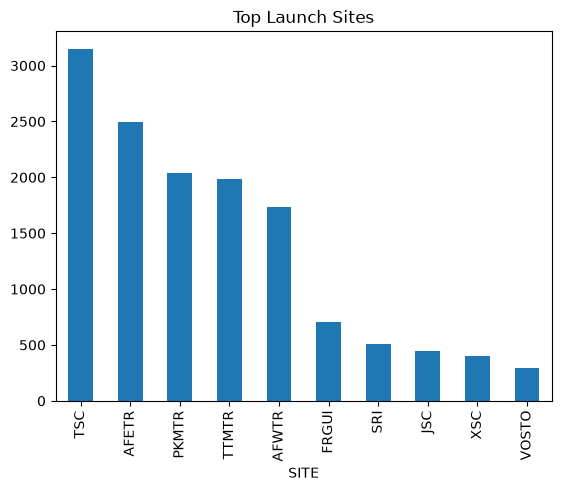

In [27]:
launch_site.sort_values(
    ascending=False
).head(10).plot(
    kind='bar'
)

plt.title('Top Launch Sites')
plt.show()

In [28]:
country_height = df.groupby(
    'COUNTRY_CODE'
)['SEMIMAJOR_AXIS'].mean()

print(
    country_height.sort_values(
        ascending=False
    ).head(10)
)

COUNTRY_CODE
USBZ    42573.538000
AGO     42417.204000
RASC    42336.030500
SES     42192.115730
ITSO    42181.104686
STCT    42165.580000
BERM    42165.474000
QAT     42165.208000
LAOS    42165.162000
FRIT    42165.076000
Name: SEMIMAJOR_AXIS, dtype: float64


In [29]:
country_type = df.groupby(
    ['COUNTRY_CODE','OBJECT_TYPE']
)['OBJECT_NAME'].count()

print(country_type)

COUNTRY_CODE  OBJECT_TYPE
AB            PAYLOAD          7
AC            PAYLOAD          6
AGO           PAYLOAD          1
ALG           PAYLOAD          6
ARGN          DEBRIS           1
                            ... 
US            ROCKET BODY    127
              TBA             19
USBZ          PAYLOAD          1
VENZ          PAYLOAD          3
VTNM          PAYLOAD          3
Name: OBJECT_NAME, Length: 127, dtype: int64


In [30]:
df['LAUNCH_DATE'] = pd.to_datetime(df['LAUNCH_DATE'])

df['Launch_Year'] = df['LAUNCH_DATE'].dt.year

In [31]:
launch_trend = df.groupby(
    'Launch_Year'
)['OBJECT_NAME'].count()

print(launch_trend)

Launch_Year
1970    14333
Name: OBJECT_NAME, dtype: int64


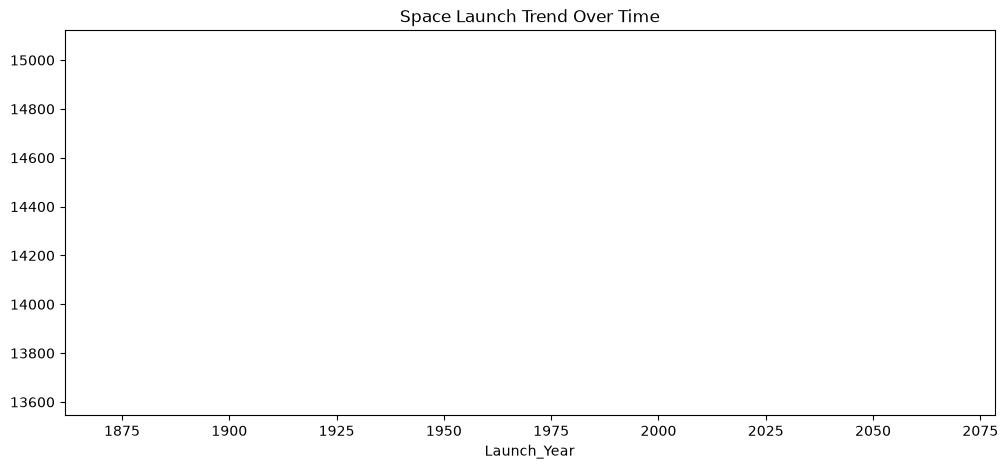

In [32]:
launch_trend.plot(
    kind='line',
    figsize=(12,5)
)

plt.title('Space Launch Trend Over Time')
plt.show()

In [33]:
df['Status'] = df['DECAY_DATE'].isnull()

df['Status'] = df['Status'].replace(
    {
        True:'Active',
        False:'Decayed'
    }
)

In [34]:
status_country = df.groupby(
    ['COUNTRY_CODE','Status']
)['OBJECT_NAME'].count()

print(status_country)

COUNTRY_CODE  Status
AB            Active       7
AC            Active       6
AGO           Active       1
ALG           Active       6
ARGN          Active      35
                        ... 
URY           Active       1
US            Active    5045
USBZ          Active       1
VENZ          Active       3
VTNM          Active       3
Name: OBJECT_NAME, Length: 99, dtype: int64
